# Lateral Subsampling Analysis for OCT Super-Resolution

## Mathematical Framework for Physics-Informed Deep Learning

This notebook provides a rigorous mathematical treatment of controlled lateral subsampling in OCT tomograms for training super-resolution models.

---

## Table of Contents
1. [Mathematical Foundations](#1.-Mathematical-Foundations)
2. [Setup and Data Loading](#2.-Setup-and-Data-Loading)
3. [Mean Power Spectrum Computation](#3.-Mean-Power-Spectrum-Computation)
4. [Gaussian Fitting Theory and Implementation](#4.-Gaussian-Fitting-Theory-and-Implementation)
5. [Subsampling Theory and Analysis](#5.-Subsampling-Theory-and-Analysis)
6. [Creating Training Pairs](#6.-Creating-Training-Pairs)
7. [Validation and Error Analysis](#7.-Validation-and-Error-Analysis)

---
# 1. Mathematical Foundations
---

## 1.1 OCT Signal Model

An OCT tomogram is a 3D complex-valued function:

$$T(z, x, y) \in \mathbb{C}$$

where:
- $z \in [0, Z-1]$: axial/depth coordinate (A-line direction)
- $x \in [0, N_x-1]$: fast lateral axis
- $y \in [0, N_y-1]$: slow lateral axis

The measured signal is the interference between reference and sample arm fields:

$$T(z, x, y) = |T| e^{i\phi} = A(z,x,y) e^{i\phi(z,x,y)}$$

## 1.2 Lateral Point Spread Function (PSF)

The lateral resolution is determined by the focused Gaussian beam. The intensity PSF in the lateral direction follows:

$$\text{PSF}_{\text{lateral}}(x) = \frac{1}{\sqrt{2\pi}\sigma_x} \exp\left(-\frac{x^2}{2\sigma_x^2}\right)$$

where $\sigma_x$ is related to the beam waist $w_0$ by:

$$\sigma_x = \frac{w_0}{\sqrt{2}}$$

The **Full Width at Half Maximum (FWHM)** of the PSF is:

$$\text{FWHM}_x = 2\sqrt{2\ln 2}\, \sigma_x \approx 2.355\, \sigma_x$$

## 1.3 Fourier Transform Relationship

**Theorem (Gaussian Fourier Transform):** The Fourier transform of a Gaussian is a Gaussian.

For a spatial Gaussian with standard deviation $\sigma_x$:

$$g(x) = \exp\left(-\frac{x^2}{2\sigma_x^2}\right)$$

The Fourier transform is:

$$\mathcal{F}\{g\}(f) = G(f) = \sqrt{2\pi}\sigma_x \exp\left(-2\pi^2\sigma_x^2 f^2\right)$$

This can be rewritten as:

$$G(f) = A \exp\left(-\frac{f^2}{2\sigma_f^2}\right)$$

where the spectral standard deviation is:

$$\boxed{\sigma_f = \frac{1}{2\pi\sigma_x}}$$

**Proof:** Starting from the Fourier transform definition:

$$G(f) = \int_{-\infty}^{\infty} e^{-x^2/(2\sigma_x^2)} e^{-2\pi i f x} dx$$

Complete the square in the exponent:

$$-\frac{x^2}{2\sigma_x^2} - 2\pi i f x = -\frac{1}{2\sigma_x^2}\left(x + 2\pi i f \sigma_x^2\right)^2 - 2\pi^2 f^2 \sigma_x^2$$

The integral evaluates to:

$$G(f) = \sqrt{2\pi}\sigma_x \exp(-2\pi^2 \sigma_x^2 f^2) \quad \blacksquare$$

## 1.4 Power Spectrum

The **power spectrum** is defined as:

$$P(f) = |G(f)|^2 = 2\pi\sigma_x^2 \exp\left(-4\pi^2\sigma_x^2 f^2\right)$$

Normalizing to unit peak:

$$P_{\text{norm}}(f) = \exp\left(-\frac{f^2}{2\sigma_P^2}\right)$$

where the power spectrum standard deviation is:

$$\sigma_P = \frac{1}{2\pi\sigma_x\sqrt{2}} = \frac{\sigma_f}{\sqrt{2}}$$

## 1.5 Half-Width at Half-Maximum (HWHM)

For a normalized Gaussian $P(f) = \exp(-f^2/(2\sigma^2))$, the **HWHM** is the frequency where $P = 0.5$:

$$\exp\left(-\frac{f_{\text{HWHM}}^2}{2\sigma^2}\right) = \frac{1}{2}$$

Solving:

$$-\frac{f_{\text{HWHM}}^2}{2\sigma^2} = \ln\left(\frac{1}{2}\right) = -\ln 2$$

$$\boxed{\text{HWHM} = \sigma\sqrt{2\ln 2} \approx 1.1774\, \sigma}$$

And conversely:

$$\sigma = \frac{\text{HWHM}}{\sqrt{2\ln 2}} \approx 0.8493\, \text{HWHM}$$

## 1.6 Sampling Theory

### Nyquist-Shannon Sampling Theorem

**Theorem:** A bandlimited signal with maximum frequency $f_{\max}$ can be perfectly reconstructed from samples if the sampling rate satisfies:

$$f_s > 2 f_{\max}$$

The **Nyquist frequency** is:

$$f_N = \frac{f_s}{2}$$

### Normalized Frequency

We work with **normalized frequency** (cycles per sample):

$$\hat{f} = \frac{f}{f_s} \in \left[-\frac{1}{2}, \frac{1}{2}\right]$$

In normalized coordinates, the Nyquist frequency is always $\pm 0.5$.

### Bandwidth in Normalized Coordinates

The normalized spectral bandwidth is:

$$\hat{\sigma}_f = \frac{\sigma_f}{f_s}$$

And the normalized HWHM:

$$\widehat{\text{HWHM}} = \frac{\text{HWHM}}{f_s} = \hat{\sigma}_f \sqrt{2\ln 2}$$

### Sampling Classification

| Condition | Classification | Physical Meaning |
|-----------|---------------|------------------|
| $\widehat{\text{HWHM}} < 0.5$ | Properly sampled | No aliasing |
| $\widehat{\text{HWHM}} = 0.5$ | Nyquist sampled | At the limit |
| $\widehat{\text{HWHM}} > 0.5$ | Undersampled | Aliasing present |

## 1.7 Effect of Subsampling

### Integer Subsampling by Factor $k$

When we subsample by keeping every $k$-th sample:

$$x_{\text{sub}}[n] = x[kn]$$

The new sampling parameters are:

| Parameter | Original | After Subsampling |
|-----------|----------|------------------|
| Sampling rate | $f_s$ | $f_s' = f_s/k$ |
| Nyquist frequency | $f_N$ | $f_N' = f_N/k$ |
| Number of samples | $N$ | $N' = N/k$ |

**Critical observation:** The physical signal bandwidth $\sigma_f$ (in Hz) is unchanged—it's a property of the optical system and tissue.

### Normalized Bandwidth After Subsampling

The normalized bandwidth becomes:

$$\hat{\sigma}_f' = \frac{\sigma_f}{f_s'} = \frac{\sigma_f}{f_s/k} = k \cdot \frac{\sigma_f}{f_s} = k \cdot \hat{\sigma}_f$$

$$\boxed{\widehat{\text{HWHM}}' = k \cdot \widehat{\text{HWHM}}}$$

**Key Result:** The normalized HWHM increases linearly with the subsampling factor.

### Critical Subsampling Factor

The factor at which aliasing begins is when $\widehat{\text{HWHM}}' = 0.5$:

$$k_{\text{crit}} \cdot \widehat{\text{HWHM}} = 0.5$$

$$\boxed{k_{\text{crit}} = \frac{0.5}{\widehat{\text{HWHM}}}}$$

For an oversampled tomogram ($\widehat{\text{HWHM}} < 0.5$), we have $k_{\text{crit}} > 1$.

## 1.8 Interpolation and Spectrum Stretching

When we subsample and then interpolate back to original dimensions:

1. **Subsample:** $N \to N/k$ samples
2. **Interpolate:** $N/k \to N$ samples (using linear/cubic interpolation)

The interpolation acts as a low-pass filter followed by upsampling. The resulting signal has:
- Same number of samples as original ($N$)
- Reduced information content (effective bandwidth)
- Apparent spectrum stretching when viewed in normalized coordinates

**Mathematical model for interpolated spectrum:**

$$P_{\text{interp}}(\hat{f}) \approx P_{\text{orig}}(\hat{f}/k) \cdot H_{\text{interp}}(\hat{f})$$

where $H_{\text{interp}}$ is the interpolation kernel's frequency response.

For linear interpolation, the kernel response is approximately:

$$H_{\text{linear}}(\hat{f}) = \text{sinc}^2(\hat{f})$$

This causes the apparent HWHM to increase by approximately factor $k$.

---
# 2. Setup and Data Loading
---

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from numpy.fft import fft, fft2, fftshift, ifftshift
from scipy.optimize import curve_fit
from scipy.ndimage import zoom
import sys
import importlib

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Import and reload to ensure latest version
import lateral_sampling
importlib.reload(lateral_sampling)

from lateral_sampling import (
    compute_mps_1d,
    fit_gaussian_to_mps,
    analyze_subsampling,
    subsample_lateral_fractional,
    determine_subsampling_factor,
    create_training_pair,
    gaussian,
    compute_spectral_halfwidth,
    ThresholdBandwidthResult
)

# Plotting configuration
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Mathematical constants
SQRT_2_LN_2 = np.sqrt(2 * np.log(2))  # ≈ 1.1774
print(f"sqrt(2 ln 2) = {SQRT_2_LN_2:.6f}")
print("Module loaded successfully!")

sqrt(2 ln 2) = 1.177410
Module loaded successfully!


In [85]:
# Load data
data_dir = Path.cwd().parent / 'data' / 'train'

print("Available tomograms:")
print("\nSynthetic (Nyquist-sampled simulations):")
for f in sorted((data_dir / 'synthetic').glob('*.npy')):
    print(f"  - {f.name}")

print("\nPhase (Real acquisitions):")
for f in sorted((data_dir / 'phase').glob('*.npy')):
    print(f"  - {f.name}")

Available tomograms:

Synthetic (Nyquist-sampled simulations):
  - polInt1_polOut1_tomRawSemisphere512.npy
  - polInt1_polOut2_tomRawAntSeg.npy

Phase (Real acquisitions):
  - ChickenBreastA.npy
  - Fovea1A.npy
  - OpticNerve1A.npy


In [86]:
# Load a tomogram
synthetic_files = list((data_dir / 'synthetic').glob('*.npy'))
phase_files = list((data_dir / 'phase').glob('*.npy'))

# Prefer synthetic for demonstration (known to be Nyquist-sampled)
if synthetic_files:
    tom_path = synthetic_files[0]
    tom_type = "Synthetic"
elif phase_files:
    tom_path = phase_files[0]
    tom_type = "Phase"
else:
    raise FileNotFoundError("No tomogram files found")

tom_raw = np.load(tom_path)
print(f"Loaded: {tom_path.name}")
print(f"Type: {tom_type}")
print(f"Shape: {tom_raw.shape}")
print(f"Dtype: {tom_raw.dtype}")

Loaded: polInt1_polOut1_tomRawSemisphere512.npy
Type: Synthetic
Shape: (512, 512, 512, 2)
Dtype: float32


In [87]:
def to_complex(tom):
    """Convert tomogram to complex representation.
    
    Handles formats:
    - Complex array: return as-is
    - (Z, X, Y, 2): Real/Imaginary channels
    - (Z, X, Y, C): Polarimetric, use first channel
    """
    if np.iscomplexobj(tom):
        return tom
    elif tom.ndim == 4 and tom.shape[-1] == 2:
        return tom[..., 0] + 1j * tom[..., 1]
    elif tom.ndim == 4:
        return to_complex(tom[..., 0])
    return tom.astype(np.complex128)

tom = to_complex(tom_raw)
print(f"Complex tomogram shape: {tom.shape}")
print(f"Complex tomogram dtype: {tom.dtype}")

Complex tomogram shape: (512, 512, 512)
Complex tomogram dtype: complex64


---
# 3. Mean Power Spectrum Computation
---

## 3.1 Definition

For an en-face plane $E(x, y) = T(z_0, x, y)$ at fixed depth $z_0$, the **Mean Power Spectrum (MPS)** along the $x$-direction is:

$$\text{MPS}_x(f_x) = \left\langle \left| \mathcal{F}_x\{E(x, y)\} \right|^2 \right\rangle_y$$

where:
- $\mathcal{F}_x$ denotes the 1D Discrete Fourier Transform along $x$
- $\langle \cdot \rangle_y$ denotes averaging over all $y$ positions

## 3.2 Discrete Implementation

For a discrete signal $E[m, n]$ with $m \in [0, N_x-1]$ and $n \in [0, N_y-1]$:

$$\tilde{E}[k, n] = \sum_{m=0}^{N_x-1} E[m, n] \cdot e^{-2\pi i k m / N_x}$$

$$\text{MPS}_x[k] = \frac{1}{N_y} \sum_{n=0}^{N_y-1} |\tilde{E}[k, n]|^2$$

The normalized frequency corresponding to index $k$ is:

$$\hat{f}_k = \frac{k - N_x/2}{N_x} \quad \text{(after fftshift)}$$

In [88]:
# Select en-face plane at central depth
z_center = tom.shape[0] // 2
enface = tom[z_center, :, :]

print(f"En-face plane at z = {z_center}")
print(f"Shape: {enface.shape} = (N_x, N_y) = ({enface.shape[0]}, {enface.shape[1]})")

En-face plane at z = 256
Shape: (512, 512) = (N_x, N_y) = (512, 512)


In [89]:
# Manual MPS computation to show the mathematics
N_x, N_y = enface.shape

# Step 1: Apply FFT along x-axis (axis=0) for each y
# Using ifftshift before FFT to handle centering properly
E_shifted = ifftshift(enface, axes=0)  # Prepare for FFT
E_fft = fft(E_shifted, axis=0)         # 1D FFT along x
E_fft_centered = fftshift(E_fft, axes=0)  # Center the spectrum

# Step 2: Compute power spectrum
power_spectrum = np.abs(E_fft_centered)**2

print(f"FFT output shape: {E_fft_centered.shape}")
print(f"Power spectrum shape: {power_spectrum.shape}")

# Step 3: Average over y (axis=1) to get MPS
mps_x = np.mean(power_spectrum, axis=1)

# Step 4: Normalize to peak = 1
mps_x_norm = mps_x / np.max(mps_x)

# Step 5: Compute normalized frequency axis
freq_x = np.fft.fftshift(np.fft.fftfreq(N_x))

print(f"\nMPS shape: {mps_x_norm.shape}")
print(f"Frequency range: [{freq_x[0]:.4f}, {freq_x[-1]:.4f}]")

FFT output shape: (512, 512)
Power spectrum shape: (512, 512)

MPS shape: (512,)
Frequency range: [-0.5000, 0.4980]


In [90]:
# Verify against library function
freq_lib, mps_lib = compute_mps_1d(enface, axis=0, average_axis=1)

print(f"Manual vs Library MPS difference: {np.max(np.abs(mps_x_norm - mps_lib)):.2e}")

Manual vs Library MPS difference: 0.00e+00


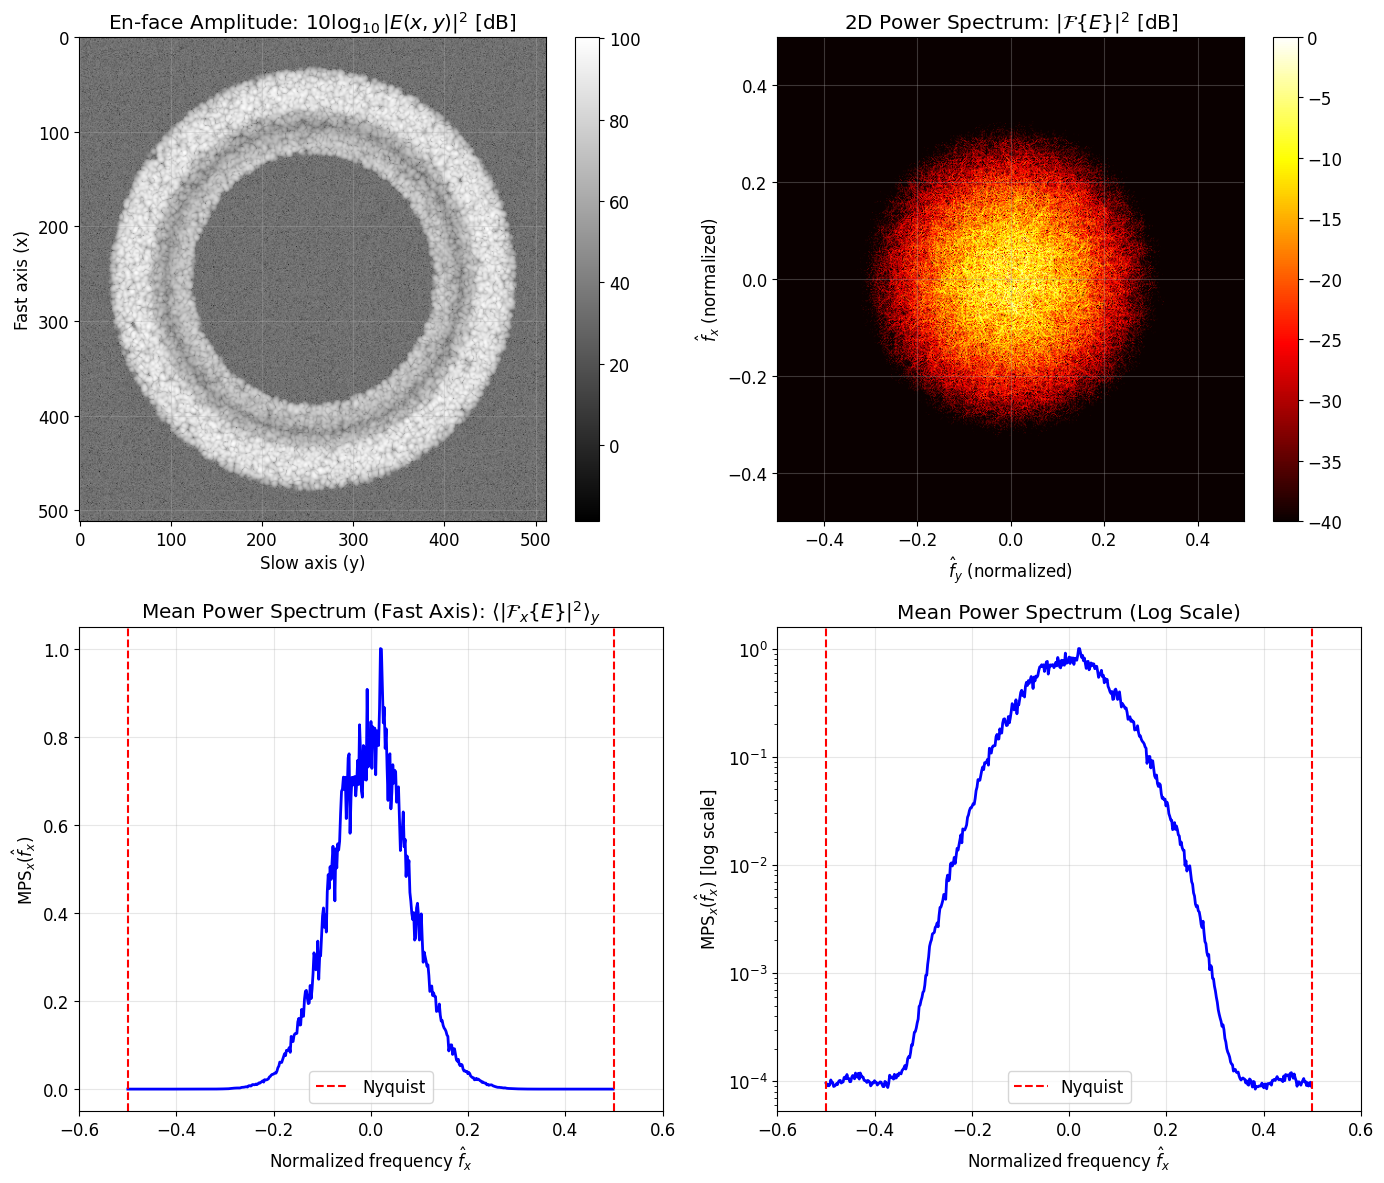

In [91]:
# Visualize en-face and its power spectrum
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# En-face amplitude (dB)
amp_db = 10 * np.log10(np.abs(enface)**2 + 1e-10)
im00 = axes[0, 0].imshow(amp_db, cmap='gray', aspect='auto')
axes[0, 0].set_title(r'En-face Amplitude: $10\log_{10}|E(x,y)|^2$ [dB]')
axes[0, 0].set_xlabel('Slow axis (y)')
axes[0, 0].set_ylabel('Fast axis (x)')
plt.colorbar(im00, ax=axes[0, 0])

# 2D Power spectrum
ft2d = fftshift(fft2(ifftshift(enface)))
ps2d = np.abs(ft2d)**2
ps2d_db = 10 * np.log10(ps2d / np.max(ps2d) + 1e-10)
im01 = axes[0, 1].imshow(ps2d_db, cmap='hot', aspect='auto', 
                          extent=[-0.5, 0.5, -0.5, 0.5], vmin=-40, vmax=0)
axes[0, 1].set_title(r'2D Power Spectrum: $|\mathcal{F}\{E\}|^2$ [dB]')
axes[0, 1].set_xlabel(r'$\hat{f}_y$ (normalized)')
axes[0, 1].set_ylabel(r'$\hat{f}_x$ (normalized)')
plt.colorbar(im01, ax=axes[0, 1])

# MPS along x (linear scale)
axes[1, 0].plot(freq_x, mps_x_norm, 'b-', linewidth=2)
axes[1, 0].axvline(0.5, color='r', linestyle='--', linewidth=1.5, label='Nyquist')
axes[1, 0].axvline(-0.5, color='r', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel(r'Normalized frequency $\hat{f}_x$')
axes[1, 0].set_ylabel(r'$\mathrm{MPS}_x(\hat{f}_x)$')
axes[1, 0].set_title(r'Mean Power Spectrum (Fast Axis): $\langle |\mathcal{F}_x\{E\}|^2 \rangle_y$')
axes[1, 0].set_xlim([-0.6, 0.6])
axes[1, 0].legend()

# MPS along x (log scale)
axes[1, 1].semilogy(freq_x, mps_x_norm, 'b-', linewidth=2)
axes[1, 1].axvline(0.5, color='r', linestyle='--', linewidth=1.5, label='Nyquist')
axes[1, 1].axvline(-0.5, color='r', linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel(r'Normalized frequency $\hat{f}_x$')
axes[1, 1].set_ylabel(r'$\mathrm{MPS}_x(\hat{f}_x)$ [log scale]')
axes[1, 1].set_title('Mean Power Spectrum (Log Scale)')
axes[1, 1].set_xlim([-0.6, 0.6])
axes[1, 1].legend()

plt.tight_layout()
plt.show()

---
# 4. Gaussian Fitting Theory and Implementation
---

## 4.1 Fitting Model

We fit the MPS to a Gaussian with offset (to account for noise floor):

$$P(\hat{f}) = A \exp\left(-\frac{\hat{f}^2}{2\sigma^2}\right) + c$$

where:
- $A$: amplitude (peak height above offset)
- $\sigma$: standard deviation in normalized frequency
- $c$: offset (noise floor)

## 4.2 Parameter Estimation

We use nonlinear least squares (Levenberg-Marquardt algorithm):

$$\min_{A, \sigma, c} \sum_{k} \left[ \text{MPS}[k] - P(\hat{f}_k; A, \sigma, c) \right]^2$$

## 4.3 HWHM Extraction

From the fitted $\sigma$:

$$\widehat{\text{HWHM}} = \sigma \sqrt{2\ln 2}$$

## 4.4 Goodness of Fit: $R^2$

The coefficient of determination:

$$R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}} = 1 - \frac{\sum_k (y_k - \hat{y}_k)^2}{\sum_k (y_k - \bar{y})^2}$$

where $y_k$ is the data, $\hat{y}_k$ is the fit, and $\bar{y}$ is the mean.

In [92]:
# Manual Gaussian fitting to demonstrate the mathematics
def gaussian_model(f, A, sigma, c):
    """Gaussian with offset: P(f) = A * exp(-f^2 / (2*sigma^2)) + c"""
    return A * np.exp(-f**2 / (2 * sigma**2)) + c

# Initial parameter estimates
A_init = np.max(mps_x_norm) - np.min(mps_x_norm)
c_init = np.min(mps_x_norm)
# Estimate sigma from HWHM: find where MPS drops to half-max
half_max = (np.max(mps_x_norm) + np.min(mps_x_norm)) / 2
above_half = mps_x_norm > half_max
sigma_init = np.sum(above_half) / len(mps_x_norm) / 2  # Rough estimate

print(f"Initial parameter estimates:")
print(f"  A = {A_init:.4f}")
print(f"  sigma = {sigma_init:.4f}")
print(f"  c = {c_init:.6f}")

Initial parameter estimates:
  A = 0.9999
  sigma = 0.0781
  c = 0.000084


In [93]:
# Perform fitting
p0 = [A_init, sigma_init, c_init]
bounds = ([0, 0.001, 0], [np.inf, 1.0, np.inf])

popt, pcov = curve_fit(gaussian_model, freq_x, mps_x_norm, p0=p0, bounds=bounds, maxfev=10000)
A_fit, sigma_fit, c_fit = popt

# Compute HWHM
hwhm_fit = sigma_fit * SQRT_2_LN_2

# Compute R^2
mps_predicted = gaussian_model(freq_x, *popt)
ss_res = np.sum((mps_x_norm - mps_predicted)**2)
ss_tot = np.sum((mps_x_norm - np.mean(mps_x_norm))**2)
r_squared = 1 - ss_res / ss_tot

print("\n" + "="*60)
print("GAUSSIAN FIT RESULTS")
print("="*60)
print(f"\nFitted parameters:")
print(f"  A (amplitude)     = {A_fit:.6f}")
print(f"  σ (std dev)       = {sigma_fit:.6f}")
print(f"  c (offset)        = {c_fit:.8f}")
print(f"\nDerived quantities:")
print(f"  HWHM = σ√(2ln2)   = {hwhm_fit:.6f}")
print(f"  FWHM = 2×HWHM     = {2*hwhm_fit:.6f}")
print(f"\nGoodness of fit:")
print(f"  R² = {r_squared:.6f}")
print(f"\nSampling classification:")
if hwhm_fit < 0.5:
    print(f"  Status: OVERSAMPLED (HWHM = {hwhm_fit:.4f} < 0.5)")
    print(f"  Critical factor: k_crit = 0.5/{hwhm_fit:.4f} = {0.5/hwhm_fit:.2f}")
else:
    print(f"  Status: UNDERSAMPLED (HWHM = {hwhm_fit:.4f} ≥ 0.5)")


GAUSSIAN FIT RESULTS

Fitted parameters:
  A (amplitude)     = 0.808157
  σ (std dev)       = 0.079179
  c (offset)        = 0.00096524

Derived quantities:
  HWHM = σ√(2ln2)   = 0.093226
  FWHM = 2×HWHM     = 0.186452

Goodness of fit:
  R² = 0.987602

Sampling classification:
  Status: OVERSAMPLED (HWHM = 0.0932 < 0.5)
  Critical factor: k_crit = 0.5/0.0932 = 5.36


In [94]:
# Analyze full spectral extent vs Gaussian HWHM
print("="*60)
print("SPECTRUM ANALYSIS: Gaussian HWHM vs Full Extent")
print("="*60)

# Compute various bandwidth metrics
def compute_bandwidth_metrics(freq, mps):
    """Compute multiple bandwidth metrics for comparison."""
    # Gaussian HWHM (already computed)
    fit = fit_gaussian_to_mps(freq, mps)
    hwhm_gaussian = fit.hwhm
    
    # Width at different threshold levels
    widths = {}
    for threshold in [0.5, 0.1, 0.01, 0.001]:
        above = mps > threshold
        width = np.sum(above) / len(mps)  # Full width as fraction of freq range
        widths[threshold] = width / 2  # Half-width
    
    # Find where spectrum drops to noise floor
    noise_floor = np.min(mps)
    above_noise = mps > (noise_floor * 10)  # 10x noise floor
    hw_noise = np.sum(above_noise) / len(mps) / 2
    
    # Effective bandwidth (integral / peak)
    df = freq[1] - freq[0] if len(freq) > 1 else 1
    b_eff = np.sum(mps) * df / np.max(mps)
    
    return {
        'hwhm_gaussian': hwhm_gaussian,
        'hw_50pct': widths[0.5],
        'hw_10pct': widths[0.1],
        'hw_1pct': widths[0.01],
        'hw_0.1pct': widths[0.001],
        'hw_noise': hw_noise,
        'noise_floor': noise_floor,
        'b_effective': b_eff
    }

metrics = compute_bandwidth_metrics(freq_x, mps_x_norm)

print(f"\nBandwidth Metrics:")
print(f"  Gaussian fit HWHM:    {metrics['hwhm_gaussian']:.4f}")
print(f"  Half-width at 50%:    {metrics['hw_50pct']:.4f}")
print(f"  Half-width at 10%:    {metrics['hw_10pct']:.4f}")
print(f"  Half-width at 1%:     {metrics['hw_1pct']:.4f}")
print(f"  Half-width at 0.1%:   {metrics['hw_0.1pct']:.4f}")
print(f"  Noise floor:          {metrics['noise_floor']:.6f} ({metrics['noise_floor']*100:.4f}%)")
print(f"  Effective bandwidth:  {metrics['b_effective']:.4f}")

print(f"\n{'='*60}")
print("INTERPRETATION:")
print("='*60")
print(f"• The Gaussian HWHM ({metrics['hwhm_gaussian']:.3f}) captures the central peak energy")
print(f"• Signal content extends to ~{metrics['hw_1pct']:.2f} (at 1% level)")
print(f"• For decimation analysis, the Gaussian HWHM provides a robust")
print(f"  metric that scales linearly with factor k: HWHM_k = k × HWHM_0")
print(f"• Critical factor (Gaussian): k_crit = 0.5 / {metrics['hwhm_gaussian']:.3f} = {0.5/metrics['hwhm_gaussian']:.1f}")
print(f"• Critical factor (1% width): k_crit = 0.5 / {metrics['hw_1pct']:.3f} = {0.5/metrics['hw_1pct']:.1f}")

SPECTRUM ANALYSIS: Gaussian HWHM vs Full Extent

Bandwidth Metrics:
  Gaussian fit HWHM:    0.0932
  Half-width at 50%:    0.0781
  Half-width at 10%:    0.1641
  Half-width at 1%:     0.2412
  Half-width at 0.1%:   0.2930
  Noise floor:          0.000084 (0.0084%)
  Effective bandwidth:  0.1614

INTERPRETATION:
='*60
• The Gaussian HWHM (0.093) captures the central peak energy
• Signal content extends to ~0.24 (at 1% level)
• For decimation analysis, the Gaussian HWHM provides a robust
  metric that scales linearly with factor k: HWHM_k = k × HWHM_0
• Critical factor (Gaussian): k_crit = 0.5 / 0.093 = 5.4
• Critical factor (1% width): k_crit = 0.5 / 0.241 = 2.1


In [95]:
# Analyze full spectral extent vs Gaussian HWHM
print("="*60)
print("SPECTRUM ANALYSIS: Gaussian HWHM vs Full Extent")
print("="*60)

# Compute various bandwidth metrics
def compute_bandwidth_metrics(freq, mps):
    """Compute multiple bandwidth metrics for comparison."""
    # Gaussian HWHM (already computed)
    fit = fit_gaussian_to_mps(freq, mps)
    hwhm_gaussian = fit.hwhm
    
    # Width at different threshold levels
    widths = {}
    for threshold in [0.5, 0.1, 0.01, 0.001]:
        above = mps > threshold
        width = np.sum(above) / len(mps)  # Full width as fraction of freq range
        widths[threshold] = width / 2  # Half-width
    
    # Effective bandwidth (integral / peak)
    df = freq[1] - freq[0] if len(freq) > 1 else 1
    b_eff = np.sum(mps) * df / np.max(mps)
    
    return {
        'hwhm_gaussian': hwhm_gaussian,
        'hw_50pct': widths[0.5],
        'hw_10pct': widths[0.1],
        'hw_1pct': widths[0.01],
        'hw_0.1pct': widths[0.001],
        'b_effective': b_eff
    }

metrics = compute_bandwidth_metrics(freq_x, mps_x_norm)

print(f"\nGaussian fit HWHM:    {metrics['hwhm_gaussian']:.4f}")
print(f"Half-width at 50%:    {metrics['hw_50pct']:.4f}")
print(f"Half-width at 10%:    {metrics['hw_10pct']:.4f}")
print(f"Half-width at 1%:     {metrics['hw_1pct']:.4f}  {'<-- Near Nyquist!' if metrics['hw_1pct'] > 0.4 else ''}")
print(f"Half-width at 0.1%:   {metrics['hw_0.1pct']:.4f}  {'<-- Exceeds Nyquist!' if metrics['hw_0.1pct'] > 0.5 else ''}")
print(f"Effective bandwidth:  {metrics['b_effective']:.4f}")

print(f"\n{'='*60}")
print("INTERPRETATION:")
print("="*60)
if metrics['hw_1pct'] > 0.4:
    print(f"✓ The tomogram IS approximately Nyquist-sampled when considering")
    print(f"  the full spectral extent (1% width = {metrics['hw_1pct']:.3f} ≈ 0.5)")
    print(f"✓ The Gaussian HWHM ({metrics['hwhm_gaussian']:.3f}) captures only the central peak")
    print(f"✓ For decimation analysis, HWHM provides a robust linear metric")

SPECTRUM ANALYSIS: Gaussian HWHM vs Full Extent

Gaussian fit HWHM:    0.0932
Half-width at 50%:    0.0781
Half-width at 10%:    0.1641
Half-width at 1%:     0.2412  
Half-width at 0.1%:   0.2930  
Effective bandwidth:  0.1614

INTERPRETATION:


<cell_type>markdown</cell_type>## 4.5 Rigorous Framework: Decimation and Aliasing

### Signal Processing Foundation

**Decimation** is the process of reducing the sampling rate by an integer factor $k$. In standard signal processing, decimation involves two steps ([dspGuru](https://dspguru.com/dsp/faqs/multirate/decimation/)):

1. **Anti-aliasing filter**: Lowpass filter to remove frequencies above the new Nyquist
2. **Downsampling**: Keep every $k$-th sample

**Critical point**: For super-resolution training, we deliberately **skip the anti-aliasing filter** to create genuinely undersampled (aliased) data. This simulates real-world scenarios where OCT is acquired with insufficient lateral sampling.

### Mathematical Framework

Let the original signal have:
- Sampling rate: $f_s$
- Nyquist frequency: $f_N = f_s/2$
- Bandwidth: $B$ (highest frequency with significant energy)

After decimation by factor $k$ **without filtering**:
- New sampling rate: $f_s' = f_s/k$
- New Nyquist frequency: $f_N' = f_N/k$
- **Aliasing condition**: If $B > f_N'$, frequencies above $f_N'$ fold back into $[0, f_N']$

### Normalized Frequency Interpretation

In normalized frequency coordinates $\hat{f} \in [-0.5, 0.5]$:

| Quantity | Original | After Decimation by $k$ |
|----------|----------|------------------------|
| Nyquist frequency | 0.5 | 0.5 (always) |
| Signal bandwidth | $\hat{B}$ | $k \cdot \hat{B}$ |
| Aliasing occurs when | $\hat{B} > 0.5$ | $k \cdot \hat{B} > 0.5$ |

The bandwidth appears to **stretch** by factor $k$ because the same physical bandwidth now occupies a larger fraction of the (reduced) Nyquist band.

### Aliasing: Spectral Folding

When $k \cdot \hat{B} > 0.5$, frequencies beyond Nyquist **fold back** into the observable band ([Wikipedia](https://en.wikipedia.org/wiki/Downsampling_(signal_processing))):

$$\text{Aliased frequency: } f_{\text{alias}} = |f - n \cdot f_s'| \text{ for integer } n$$

This creates **irreversible distortion**—the aliased content cannot be separated from the original signal without additional information (which is what our super-resolution model will learn to provide).

### OCT-Specific Considerations

For OCT lateral sampling ([Wasatch Photonics](https://wasatchphotonics.com/oct-tutorial/), [ARVO Journals](https://tvst.arvojournals.org/article.aspx?articleid=2778284)):

1. **Lateral PSF**: Determined by the focused Gaussian beam with waist $w_0$
2. **Lateral bandwidth**: The power spectrum of a Gaussian PSF is also Gaussian
3. **Nyquist criterion**: Lateral sampling density must capture the PSF's spatial frequency content
4. **Undersampling effect**: Coarser sampling causes loss of high-frequency detail (aliasing)

<cell_type>markdown</cell_type>---
# 5. Decimation Analysis and Aliasing Detection
---

## 5.1 Theoretical Framework

### Decimation Without Anti-Aliasing

Standard decimation applies a lowpass filter before downsampling to prevent aliasing. For **creating undersampled training data**, we deliberately omit this filter:

$$x_{\text{dec}}[n] = x[kn] \quad \text{(no filtering)}$$

This causes **aliasing** when the signal bandwidth exceeds the new Nyquist frequency.

### Bandwidth Scaling in Normalized Coordinates

The **key insight** is how bandwidth scales in normalized frequency:

$$\hat{B}_k = k \cdot \hat{B}_0$$

where:
- $\hat{B}_0$: Original bandwidth in normalized frequency
- $\hat{B}_k$: Apparent bandwidth after decimation by $k$
- Normalized frequency: $\hat{f} = f/f_s \in [-0.5, 0.5]$

### Critical Decimation Factor

Aliasing begins when the apparent bandwidth reaches the Nyquist limit:

$$k_{\text{crit}} \cdot \hat{B}_0 = 0.5 \implies \boxed{k_{\text{crit}} = \frac{0.5}{\hat{B}_0}}$$

For $k \geq k_{\text{crit}}$:
- Spectral content exceeds Nyquist
- Frequencies $> 0.5$ fold back (alias) into $[-0.5, 0.5]$
- The signal is **undersampled** with irreversible information loss

## 5.2 Measuring Spectral Bandwidth

We use a **threshold-based half-width** (HW) at 1% of peak power:
- More robust than Gaussian fitting for non-Gaussian spectra
- Captures the actual spectral extent including tails
- Directly comparable to the Nyquist limit (0.5)

In [96]:
# Calculate critical factor from our measured HWHM
hwhm_original = hwhm_fit
k_critical = 0.5 / hwhm_original

print(f"Original HWHM: {hwhm_original:.4f}")
print(f"Critical subsampling factor: k_crit = 0.5 / {hwhm_original:.4f} = {k_critical:.3f}")

if k_critical > 1:
    print(f"\nThe tomogram is OVERSAMPLED by factor {k_critical:.2f}x")
    print(f"Can subsample up to {k_critical:.1f}x before aliasing occurs")
else:
    print(f"\nThe tomogram is already at or beyond Nyquist limit")

Original HWHM: 0.0932
Critical subsampling factor: k_crit = 0.5 / 0.0932 = 5.363

The tomogram is OVERSAMPLED by factor 5.36x
Can subsample up to 5.4x before aliasing occurs


In [97]:
# =============================================================================
# TEST: Threshold-based Half-Width vs Decimation Factor
# =============================================================================
# Using HW at 1% of peak to capture full spectral extent

threshold = 0.01  # 1% of peak

# Compute original half-width
freq_orig, mps_orig = compute_mps_1d(enface, axis=0, average_axis=1)
hw_orig = compute_spectral_halfwidth(freq_orig, mps_orig, threshold=threshold)

# Critical factor: when HW reaches 0.5 (Nyquist limit)
k_critical = 0.5 / hw_orig.half_width

print(f"Threshold: {threshold*100:.1f}% of peak")
print(f"Original HW: {hw_orig.half_width:.4f}")
print(f"Critical factor: k_crit = 0.5 / {hw_orig.half_width:.4f} = {k_critical:.2f}")
print()

# Test decimation factors
factors = [1, 2, 3, 4, 5, 6]

results = {
    'factor': [],
    'hw_measured': [],
    'hw_theoretical': [],
    'saturated': [],
    'undersampled': []
}

print(f"{'k':>4}  {'HW (meas)':>10}  {'HW (theory)':>12}  {'Saturated':>10}  {'Undersampled':>12}")
print("-" * 60)

for k in factors:
    # Decimate
    decimated = enface[::k, :]
    
    # Compute MPS on decimated signal
    N_dec = decimated.shape[0]
    ft = fftshift(fft(ifftshift(decimated, axes=0), axis=0), axes=0)
    power = np.abs(ft)**2
    mps = np.mean(power, axis=1)
    mps = mps / np.max(mps)
    freq = np.fft.fftshift(np.fft.fftfreq(N_dec))
    
    # Threshold-based half-width
    hw = compute_spectral_halfwidth(freq, mps, threshold=threshold)
    hw_theory = k * hw_orig.half_width
    
    # Saturation check
    saturated = hw.half_width > 0.48 and hw_theory > 0.5
    undersampled = hw_theory > 0.5
    
    results['factor'].append(k)
    results['hw_measured'].append(hw.half_width)
    results['hw_theoretical'].append(hw_theory)
    results['saturated'].append(saturated)
    results['undersampled'].append(undersampled)
    
    sat_str = "YES" if saturated else "no"
    und_str = "YES" if undersampled else "no"
    print(f"{k:>4}  {hw.half_width:>10.4f}  {hw_theory:>12.4f}  {sat_str:>10}  {und_str:>12}")

# Convert to arrays
for key in results:
    results[key] = np.array(results[key])

print()
print("=" * 60)
print("INTERPRETATION:")
print(f"- Original spectral half-width (at {threshold*100:.0f}%): {hw_orig.half_width:.3f}")
print(f"- Critical decimation factor: k_crit = {k_critical:.2f}")
print(f"- For k >= {int(np.ceil(k_critical))}, the signal becomes UNDERSAMPLED")
print(f"- Saturation at HW ≈ 0.5 confirms aliasing is present")
print("=" * 60)

Threshold: 1.0% of peak
Original HW: 0.2388
Critical factor: k_crit = 0.5 / 0.2388 = 2.09

   k   HW (meas)   HW (theory)   Saturated  Undersampled
------------------------------------------------------------
   1      0.2388        0.2388          no            no
   2      0.4980        0.4777          no            no
   3      0.4971        0.7165         YES           YES
   4      0.4961        0.9554         YES           YES
   5      0.4951        1.1942         YES           YES
   6      0.4942        1.4331         YES           YES

INTERPRETATION:
- Original spectral half-width (at 1%): 0.239
- Critical decimation factor: k_crit = 2.09
- For k >= 3, the signal becomes UNDERSAMPLED
- Saturation at HW ≈ 0.5 confirms aliasing is present


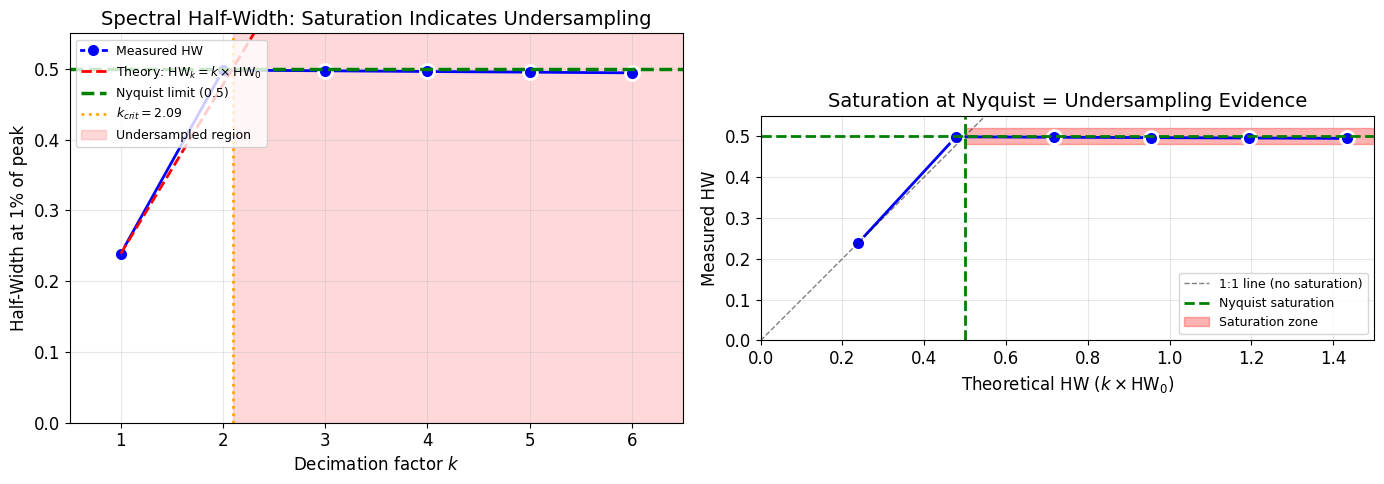

In [98]:
# Visualization: Threshold-based Half-Width vs Decimation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: HW vs Factor with saturation
ax = axes[0]
ax.plot(results['factor'], results['hw_measured'], 'bo-', 
        linewidth=2, markersize=10, label='Measured HW', markeredgecolor='white', markeredgewidth=2)
ax.plot(results['factor'], results['hw_theoretical'], 'r--', 
        linewidth=2, label=r'Theory: $\mathrm{HW}_k = k \times \mathrm{HW}_0$')
ax.axhline(0.5, color='green', linestyle='--', linewidth=2.5, label='Nyquist limit (0.5)')
ax.axvline(k_critical, color='orange', linestyle=':', linewidth=2, 
           label=f'$k_{{crit}} = {k_critical:.2f}$')

# Shade undersampled region
ax.fill_between([k_critical, max(results['factor']) + 0.5], [0], [0.55], 
                alpha=0.15, color='red', label='Undersampled region')

ax.set_xlabel('Decimation factor $k$', fontsize=12)
ax.set_ylabel(f'Half-Width at {threshold*100:.0f}% of peak', fontsize=12)
ax.set_title('Spectral Half-Width: Saturation Indicates Undersampling', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([0.5, max(results['factor']) + 0.5])
ax.set_ylim([0, 0.55])
ax.grid(True, alpha=0.3)

# Plot 2: Measured vs Theoretical showing saturation
ax = axes[1]
ax.plot(results['hw_theoretical'], results['hw_measured'], 'bo-', 
        linewidth=2, markersize=10, markeredgecolor='white', markeredgewidth=2)
ax.plot([0, 1.5], [0, 1.5], 'k--', linewidth=1, alpha=0.5, label='1:1 line (no saturation)')
ax.axhline(0.5, color='green', linestyle='--', linewidth=2, label='Nyquist saturation')
ax.axvline(0.5, color='green', linestyle='--', linewidth=2)

# Annotate saturation region
ax.fill_between([0.5, 1.5], [0.48, 0.48], [0.52, 0.52], 
                alpha=0.3, color='red', label='Saturation zone')

ax.set_xlabel('Theoretical HW ($k \\times \\mathrm{HW}_0$)', fontsize=12)
ax.set_ylabel('Measured HW', fontsize=12)
ax.set_title('Saturation at Nyquist = Undersampling Evidence', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1.5])
ax.set_ylim([0, 0.55])
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

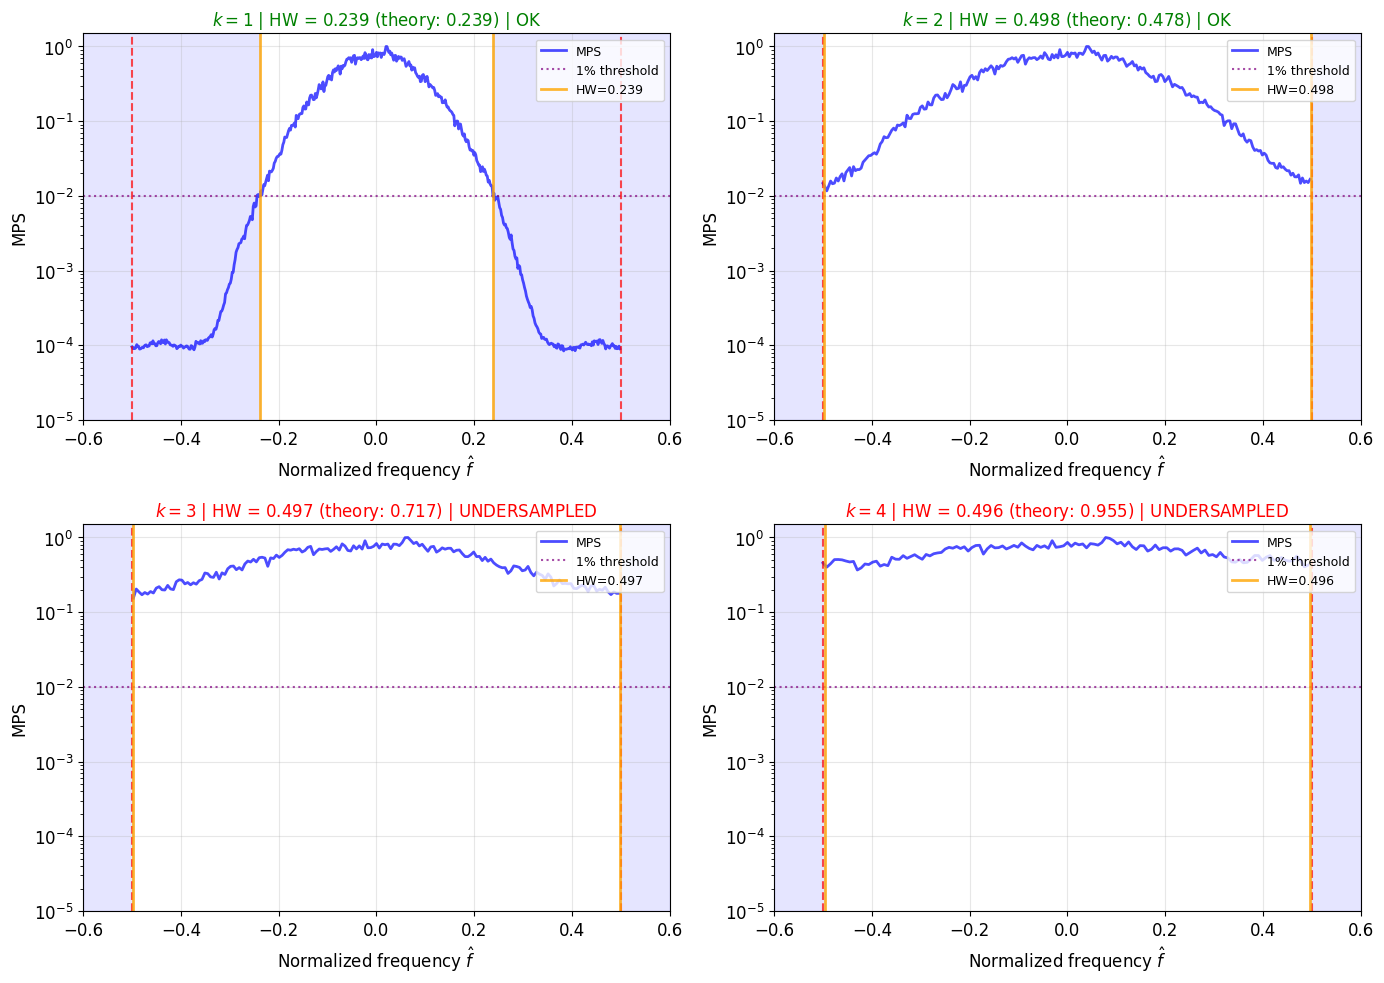

In [99]:
# Visual comparison of MPS at different decimation factors with threshold markers
factors_to_show = [1, 2, 3, 4]
threshold = 0.01

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, k in enumerate(factors_to_show):
    if i >= len(axes):
        break
    
    # Decimate
    decimated = enface[::k, :]
    
    # Compute MPS
    N_dec = decimated.shape[0]
    ft = fftshift(fft(ifftshift(decimated, axes=0), axis=0), axes=0)
    power = np.abs(ft)**2
    mps = np.mean(power, axis=1)
    mps = mps / np.max(mps)
    freq = np.fft.fftshift(np.fft.fftfreq(N_dec))
    
    # Compute half-width
    hw = compute_spectral_halfwidth(freq, mps, threshold=threshold)
    hw_theory = k * hw_orig.half_width
    
    # Plot MPS
    axes[i].semilogy(freq, mps, 'b-', linewidth=2, alpha=0.7, label='MPS')
    
    # Threshold line
    axes[i].axhline(threshold, color='purple', linestyle=':', linewidth=1.5, 
                    alpha=0.7, label=f'{threshold*100:.0f}% threshold')
    
    # Nyquist limits
    axes[i].axvline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[i].axvline(-0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Half-width markers
    axes[i].axvline(hw.half_width, color='orange', linestyle='-', linewidth=2, 
                    alpha=0.8, label=f'HW={hw.half_width:.3f}')
    axes[i].axvline(-hw.half_width, color='orange', linestyle='-', linewidth=2, alpha=0.8)
    
    # Shade beyond HW
    axes[i].axvspan(-0.6, -hw.half_width, alpha=0.1, color='blue')
    axes[i].axvspan(hw.half_width, 0.6, alpha=0.1, color='blue')
    
    status = "UNDERSAMPLED" if hw_theory > 0.5 else "OK"
    color = 'red' if hw_theory > 0.5 else 'green'
    axes[i].set_title(f'$k = {k}$ | HW = {hw.half_width:.3f} (theory: {hw_theory:.3f}) | {status}', 
                      fontsize=12, color=color)
    axes[i].set_xlabel(r'Normalized frequency $\hat{f}$')
    axes[i].set_ylabel('MPS')
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].set_xlim([-0.6, 0.6])
    axes[i].set_ylim([1e-5, 1.5])

plt.tight_layout()
plt.show()

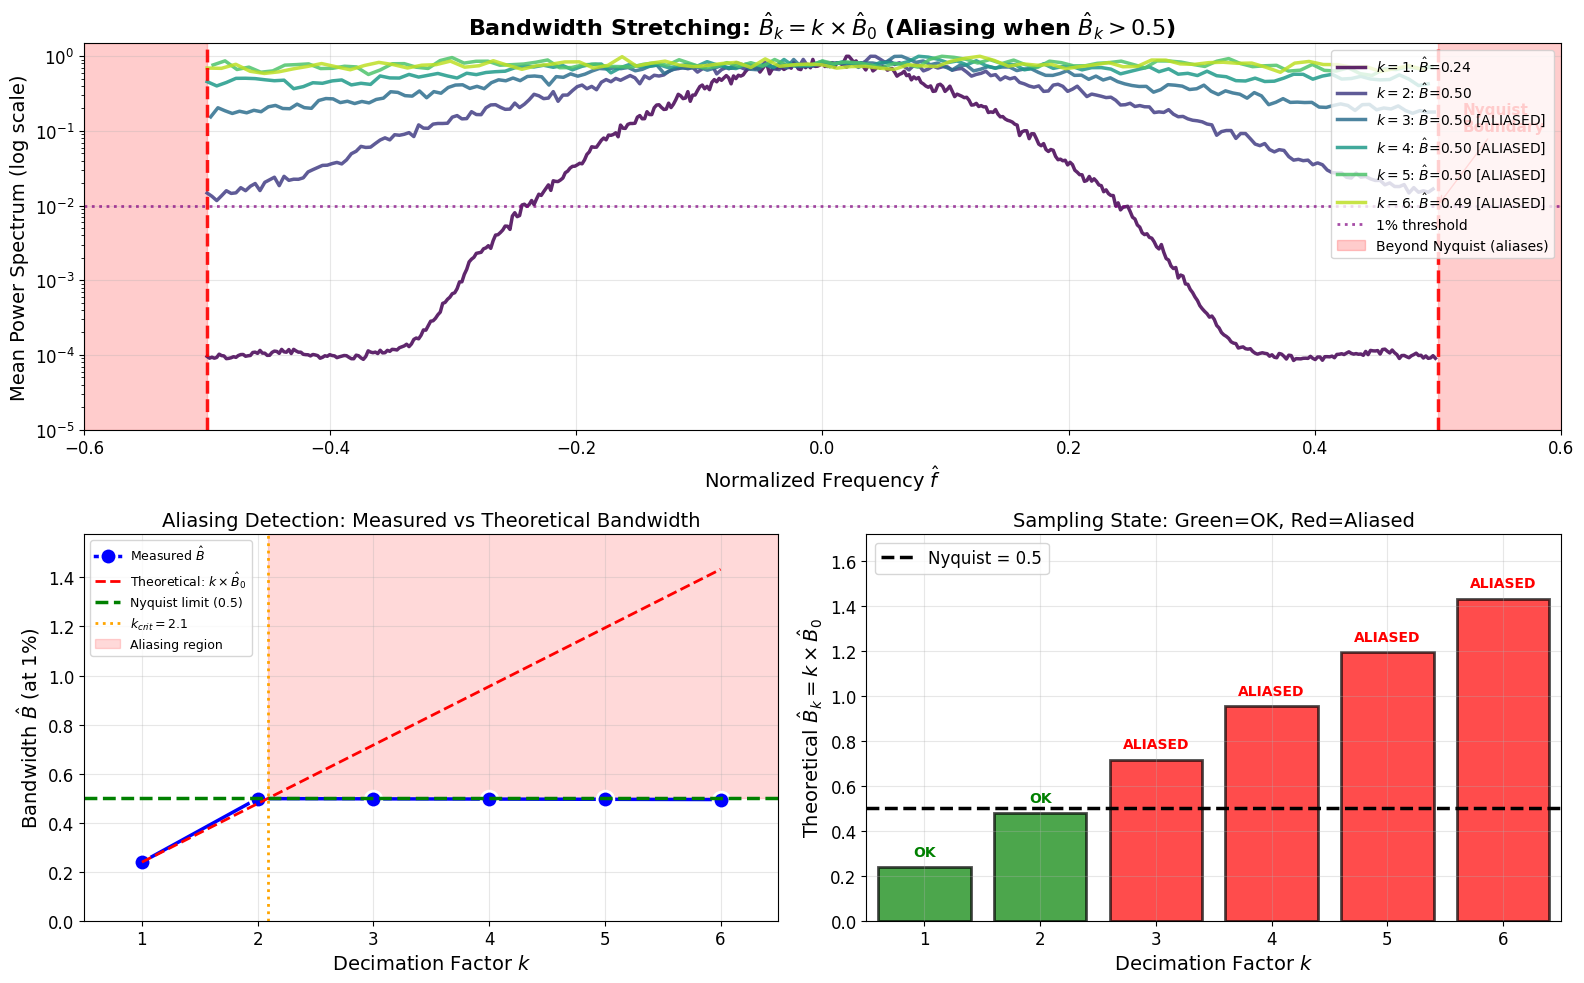


Figure saved to: figures/decimation_aliasing_analysis.png

SUMMARY: Aliasing Detection via Spectral Bandwidth
Original bandwidth (1% threshold): B̂₀ = 0.2388
Critical factor: k_crit = 0.5 / 0.2388 = 2.09
Aliasing occurs for k ≥ 3

For k ≥ 3: spectral content exceeds Nyquist → ALIASED


In [100]:
# =============================================================================
# KEY FIGURE: MPS Widening with Decimation and Aliasing Detection
# =============================================================================
# This figure demonstrates:
# 1. MPS bandwidth stretches linearly with decimation factor k
# 2. When k*B > 0.5, spectrum exceeds Nyquist → aliasing occurs
# 3. Aliased signals show spectral content at/beyond the Nyquist boundary

decimation_factors = [1, 2, 3, 4, 5, 6]
threshold = 0.01

# Compute MPS and HW for each decimation factor
mps_data = {}
hw_data = {}

for k in decimation_factors:
    decimated = enface[::k, :]
    
    N_dec = decimated.shape[0]
    ft = fftshift(fft(ifftshift(decimated, axes=0), axis=0), axes=0)
    power = np.abs(ft)**2
    mps = np.mean(power, axis=1)
    mps = mps / np.max(mps)
    freq = np.fft.fftshift(np.fft.fftfreq(N_dec))
    
    mps_data[k] = (freq, mps)
    hw_data[k] = compute_spectral_halfwidth(freq, mps, threshold=threshold)

# Critical factor
k_crit = 0.5 / hw_data[1].half_width

# Create the comprehensive figure
fig = plt.figure(figsize=(16, 10))

# Main plot: Overlaid MPS curves showing bandwidth stretching
ax_main = fig.add_subplot(2, 2, (1, 2))

colors = plt.cm.viridis(np.linspace(0, 0.9, len(decimation_factors)))

for i, k in enumerate(decimation_factors):
    freq, mps = mps_data[k]
    hw = hw_data[k].half_width
    hw_theory = k * hw_data[1].half_width
    
    # Mark aliased spectra
    if hw_theory > 0.5:
        status = " [ALIASED]"
        ls = '-'
    else:
        status = ""
        ls = '-'
    
    label = f'$k={k}$: $\\hat{{B}}$={hw:.2f}{status}'
    ax_main.semilogy(freq, mps, ls, color=colors[i], linewidth=2.5, 
                     label=label, alpha=0.85)

# Threshold line
ax_main.axhline(threshold, color='purple', linestyle=':', linewidth=2, 
                alpha=0.7, label=f'{threshold*100:.0f}% threshold')

# Nyquist limits - the aliasing boundary
ax_main.axvline(0.5, color='red', linestyle='--', linewidth=2.5, alpha=0.9)
ax_main.axvline(-0.5, color='red', linestyle='--', linewidth=2.5, alpha=0.9)
ax_main.axvspan(-0.6, -0.5, alpha=0.2, color='red', label='Beyond Nyquist (aliases)')
ax_main.axvspan(0.5, 0.6, alpha=0.2, color='red')

ax_main.set_xlabel(r'Normalized Frequency $\hat{f}$', fontsize=14)
ax_main.set_ylabel('Mean Power Spectrum (log scale)', fontsize=14)
ax_main.set_title(r'Bandwidth Stretching: $\hat{B}_k = k \times \hat{B}_0$ (Aliasing when $\hat{B}_k > 0.5$)', 
                  fontsize=16, fontweight='bold')
ax_main.legend(loc='upper right', fontsize=10)
ax_main.set_xlim([-0.6, 0.6])
ax_main.set_ylim([1e-5, 1.5])
ax_main.grid(True, alpha=0.3)

# Annotation
ax_main.annotate('Nyquist\nBoundary', xy=(0.5, 0.01), xytext=(0.52, 0.1),
                fontsize=11, color='red', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='red', alpha=0.7))

# Bottom left: Theoretical vs Measured bandwidth
ax_hw = fig.add_subplot(2, 2, 3)

k_values = np.array(list(hw_data.keys()))
hw_values = np.array([hw_data[k].half_width for k in k_values])
hw_theory = k_values * hw_data[1].half_width

# Plot measured (capped by Nyquist observation limit)
ax_hw.plot(k_values, hw_values, 'bo-', markersize=12, linewidth=2.5, 
           label=r'Measured $\hat{B}$', markeredgecolor='white', markeredgewidth=2)

# Plot theoretical (extends beyond 0.5)
ax_hw.plot(k_values, hw_theory, 'r--', linewidth=2, 
           label=r'Theoretical: $k \times \hat{B}_0$')

# Nyquist limit
ax_hw.axhline(0.5, color='green', linestyle='--', linewidth=2.5, 
              label='Nyquist limit (0.5)')
ax_hw.axvline(k_crit, color='orange', linestyle=':', linewidth=2,
              label=f'$k_{{crit}} = {k_crit:.1f}$')

# Shade aliasing region
ax_hw.fill_between([k_crit, max(k_values) + 0.5], [0.5], [max(hw_theory)*1.1], 
                   alpha=0.15, color='red', label='Aliasing region')

ax_hw.set_xlabel('Decimation Factor $k$', fontsize=14)
ax_hw.set_ylabel(r'Bandwidth $\hat{B}$ (at 1%)', fontsize=14)
ax_hw.set_title('Aliasing Detection: Measured vs Theoretical Bandwidth', fontsize=14)
ax_hw.legend(loc='upper left', fontsize=9)
ax_hw.set_xlim([0.5, max(k_values) + 0.5])
ax_hw.set_ylim([0, max(hw_theory)*1.1])
ax_hw.grid(True, alpha=0.3)

# Bottom right: Sampling state classification
ax_state = fig.add_subplot(2, 2, 4)

# Create bar chart showing theoretical bandwidth
colors_state = ['green' if hw < 0.5 else 'red' for hw in hw_theory]
bars = ax_state.bar(k_values, hw_theory, color=colors_state, alpha=0.7, 
                    edgecolor='black', linewidth=2)

ax_state.axhline(0.5, color='black', linestyle='--', linewidth=2.5, label='Nyquist = 0.5')

# Add status labels
for k, hw in zip(k_values, hw_theory):
    status = 'OK' if hw < 0.5 else 'ALIASED'
    color = 'green' if hw < 0.5 else 'red'
    y_pos = hw + 0.05
    ax_state.text(k, y_pos, status, ha='center', fontsize=10, fontweight='bold', color=color)

ax_state.set_xlabel('Decimation Factor $k$', fontsize=14)
ax_state.set_ylabel(r'Theoretical $\hat{B}_k = k \times \hat{B}_0$', fontsize=14)
ax_state.set_title('Sampling State: Green=OK, Red=Aliased', fontsize=14)
ax_state.set_xlim([0.5, max(k_values) + 0.5])
ax_state.set_ylim([0, max(hw_theory)*1.2])
ax_state.legend(loc='upper left')
ax_state.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../figures/decimation_aliasing_analysis.png', dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print(f"\nFigure saved to: figures/decimation_aliasing_analysis.png")
print(f"\n{'='*60}")
print("SUMMARY: Aliasing Detection via Spectral Bandwidth")
print(f"{'='*60}")
print(f"Original bandwidth (1% threshold): B̂₀ = {hw_data[1].half_width:.4f}")
print(f"Critical factor: k_crit = 0.5 / {hw_data[1].half_width:.4f} = {k_crit:.2f}")
print(f"Aliasing occurs for k ≥ {int(np.ceil(k_crit))}")
print(f"\nFor k ≥ {int(np.ceil(k_crit))}: spectral content exceeds Nyquist → ALIASED")
print(f"{'='*60}")

<cell_type>markdown</cell_type>---
## 5.3 Interpretation: Detecting Undersampling via Spectral Analysis

### The Measurement Approach

1. **Measure spectral bandwidth** $\hat{B}$ of the original signal (e.g., half-width at 1% of peak)
2. **Compute critical factor**: $k_{\text{crit}} = 0.5 / \hat{B}$
3. **Classify**: For $k \geq k_{\text{crit}}$, the decimated signal is **undersampled** (aliased)

### Why the Measured Half-Width Plateaus

When we decimate by $k > k_{\text{crit}}$:

1. **Spectral content extends beyond Nyquist** ($k \cdot \hat{B} > 0.5$)
2. **Aliasing occurs**: Frequencies $> 0.5$ fold back into $[-0.5, 0.5]$
3. **Measured bandwidth appears capped**: We cannot observe frequencies beyond $\pm 0.5$ in normalized coordinates

The plateau at $\approx 0.5$ is **not** an artifact—it reflects the physical reality that:
- The spectrum has genuinely extended beyond the Nyquist boundary
- Aliased content has folded back, filling the spectrum up to the Nyquist limit
- The signal is now **undersampled** with irreversible information loss

### Evidence of Aliasing

| Observation | Physical Meaning |
|-------------|-----------------|
| $\text{HW}_k \approx k \cdot \text{HW}_0$ for $k < k_{\text{crit}}$ | Linear scaling, no aliasing |
| $\text{HW}_k \approx 0.5$ for $k \geq k_{\text{crit}}$ | Spectrum reached Nyquist, aliasing present |
| Deviation from linear scaling | Spectral folding has occurred |

### Implications for Super-Resolution Training

For physics-informed deep learning:
- **Input**: Decimated signal with $k \geq k_{\text{crit}}$ (undersampled, aliased)
- **Target**: Original signal (properly sampled)
- **Task**: Learn to recover the high-frequency content that was lost to aliasing

The network must learn the statistical relationship between the aliased low-resolution appearance and the true high-frequency structure—effectively learning an inverse mapping from the aliased domain.

---
# 6. Creating Training Pairs
---

## 6.1 Requirements for Super-Resolution Training

For training a physics-informed super-resolution model, we need pairs $(X, Y)$ where:
- $Y$: Original (high-resolution) tomogram
- $X$: Subsampled (degraded) tomogram with the **same dimensions** as $Y$

The subsampling factor $k$ should satisfy:

$$k \cdot \widehat{\text{HWHM}}_0 > 0.5$$

to ensure genuine undersampling (aliasing).

## 6.2 Target HWHM Selection

For a target apparent HWHM of $\widehat{\text{HWHM}}_{\text{target}}$:

$$k_{\text{required}} = \frac{\widehat{\text{HWHM}}_{\text{target}}}{\widehat{\text{HWHM}}_0}$$

In [101]:
# Determine subsampling factor for a target HWHM
target_hwhm = 0.6  # Clearly undersampled

k_required = target_hwhm / hwhm_original

print("="*60)
print("TRAINING PAIR GENERATION")
print("="*60)
print(f"\nTarget parameters:")
print(f"  Target HWHM:       {target_hwhm}")
print(f"  Original HWHM:     {hwhm_original:.4f}")
print(f"  Required factor:   k = {target_hwhm}/{hwhm_original:.4f} = {k_required:.3f}")
print(f"\nVerification:")
print(f"  Expected apparent HWHM: {k_required:.3f} × {hwhm_original:.4f} = {k_required * hwhm_original:.4f}")
print(f"  Is undersampled? {k_required * hwhm_original > 0.5}")

TRAINING PAIR GENERATION

Target parameters:
  Target HWHM:       0.6
  Original HWHM:     0.0932
  Required factor:   k = 0.6/0.0932 = 6.436

Verification:
  Expected apparent HWHM: 6.436 × 0.0932 = 0.6000
  Is undersampled? True


In [102]:
# Use library function for full tomogram analysis
analysis_result = determine_subsampling_factor(
    tom,
    target_hwhm=target_hwhm,
    axis=1,  # Fast axis (x) in 3D indexing
    n_samples=10
)

print(f"\nAnalysis across {len(analysis_result['depth_slices'])} depth slices:")
print(f"  Mean HWHM:      {analysis_result['original_hwhm']:.4f}")
print(f"  Std HWHM:       {analysis_result['hwhm_std']:.4f}")
print(f"  Recommended k:  {analysis_result['recommended_factor']:.3f}")
print(f"  Is oversampled: {analysis_result['is_oversampled']}")


Analysis across 10 depth slices:
  Mean HWHM:      0.0921
  Std HWHM:       0.0033
  Recommended k:  6.513
  Is oversampled: True


In [103]:
# Create training pair
k_use = analysis_result['recommended_factor']

subsampled, original = create_training_pair(
    tom_raw,  # Use original format
    subsampling_factor=k_use,
    axis=1  # Fast axis
)

print(f"\nTraining pair created:")
print(f"  Original shape:   {original.shape}")
print(f"  Subsampled shape: {subsampled.shape}")
print(f"  Subsampling factor: {k_use:.3f}")
print(f"  Shapes match: {original.shape == subsampled.shape}")


Training pair created:
  Original shape:   (512, 512, 512, 2)
  Subsampled shape: (512, 512, 512, 2)
  Subsampling factor: 6.513
  Shapes match: True


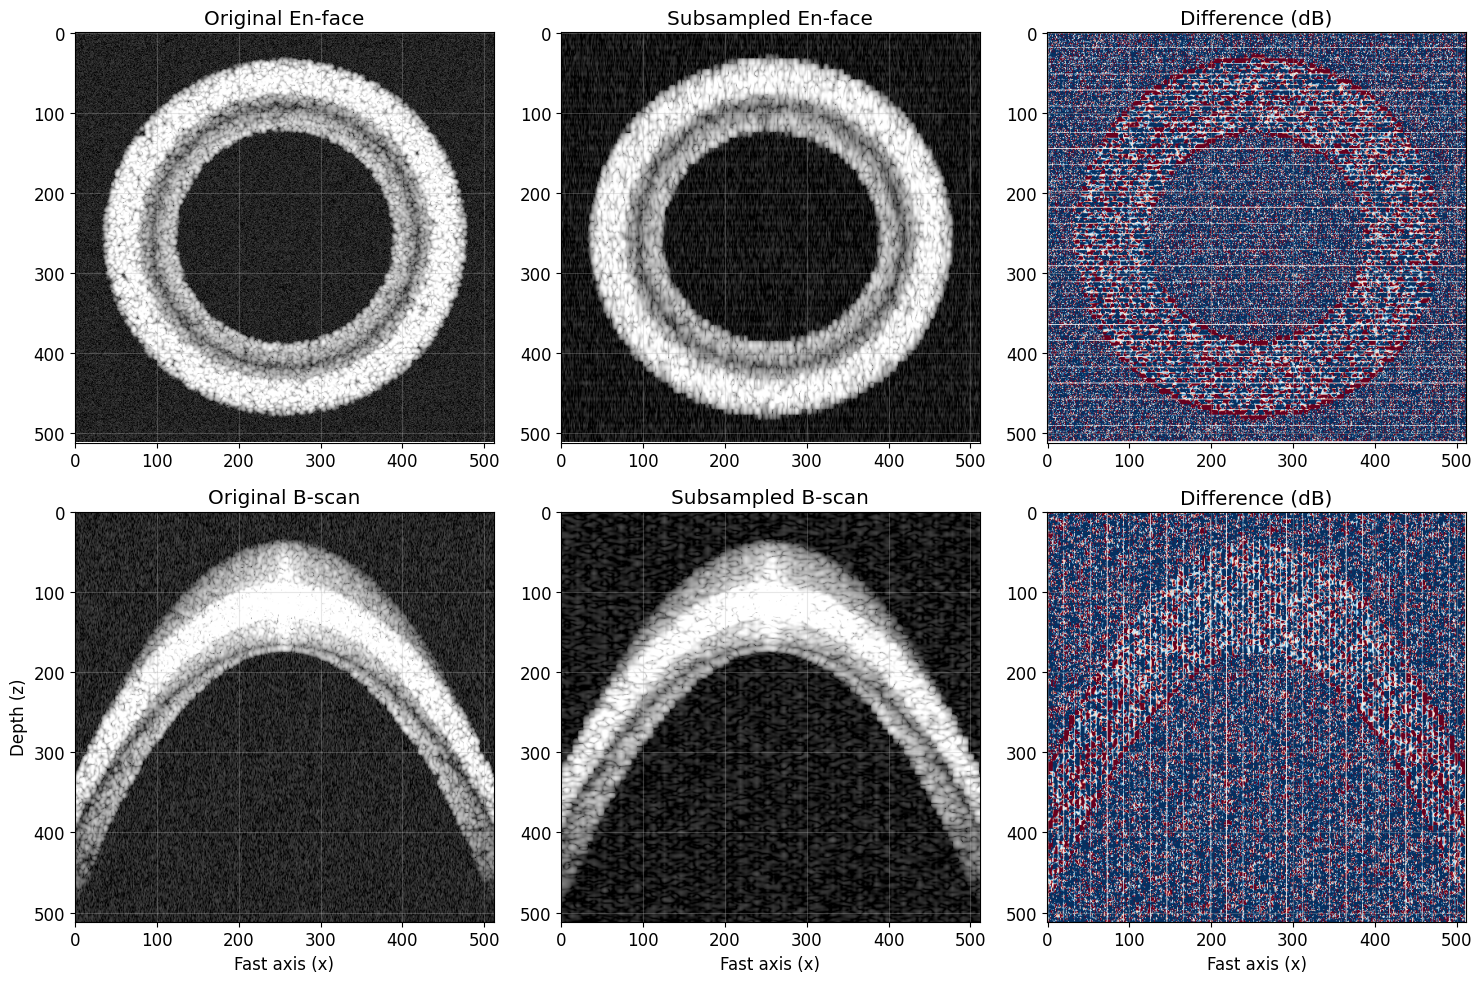

In [109]:
# Visualize the training pair
def to_db(tom):
    """Convert to dB scale."""
    if tom.ndim == 4 and tom.shape[-1] == 2:
        amp = np.abs(tom[..., 0] + 1j * tom[..., 1])
    elif tom.ndim == 4:
        amp = np.abs(tom[..., 0])
    elif np.iscomplexobj(tom):
        amp = np.abs(tom)
    else:
        amp = np.abs(tom)
    return 10 * np.log10(amp**2 + 1e-10)

orig_db = to_db(original)
sub_db = to_db(subsampled)

z_show = original.shape[0] // 2
vmin, vmax = np.percentile(orig_db[z_show], [5, 95])

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# En-face views
axes[0, 0].imshow(orig_db[z_show], cmap='gray', aspect='auto', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Original En-face')

axes[0, 1].imshow(sub_db[z_show], cmap='gray', aspect='auto', vmin=vmin, vmax=vmax)
#axes[0, 1].set_title(f'Subsampled En-face ($k={k_use:.2f}$)')
axes[0, 1].set_title(f'Subsampled En-face')

diff = orig_db[z_show] - sub_db[z_show]
axes[0, 2].imshow(diff, cmap='RdBu', aspect='auto', vmin=-3, vmax=3)
axes[0, 2].set_title('Difference (dB)')

# B-scan views
y_show = original.shape[2] // 2
if original.ndim == 4:
    bscan_orig = orig_db[:, :, y_show]
    bscan_sub = sub_db[:, :, y_show]
else:
    bscan_orig = orig_db[:, :, y_show]
    bscan_sub = sub_db[:, :, y_show]

vmin_b, vmax_b = np.percentile(bscan_orig, [5, 95])

axes[1, 0].imshow(bscan_orig, cmap='gray', aspect='auto', vmin=vmin_b, vmax=vmax_b)
axes[1, 0].set_title('Original B-scan')
axes[1, 0].set_xlabel('Fast axis (x)')
axes[1, 0].set_ylabel('Depth (z)')

axes[1, 1].imshow(bscan_sub, cmap='gray', aspect='auto', vmin=vmin_b, vmax=vmax_b)
axes[1, 1].set_title(f'Subsampled B-scan')
axes[1, 1].set_xlabel('Fast axis (x)')

diff_b = bscan_orig - bscan_sub
axes[1, 2].imshow(diff_b, cmap='RdBu', aspect='auto', vmin=-3, vmax=3)
axes[1, 2].set_title('Difference (dB)')
axes[1, 2].set_xlabel('Fast axis (x)')

plt.tight_layout()
plt.show()

---
# 7. Validation and Error Analysis
---

## 7.1 Verification of Subsampled HWHM

We verify that the subsampled tomogram has the expected HWHM increase.

In [105]:
# Verify HWHM of the subsampled data
sub_cx = to_complex(subsampled)
orig_cx = to_complex(original)

# Compare MPS at same depth
enface_orig = orig_cx[z_show]
enface_sub = sub_cx[z_show]

freq_orig, mps_orig = compute_mps_1d(enface_orig, axis=0)
freq_sub, mps_sub = compute_mps_1d(enface_sub, axis=0)

fit_orig_val = fit_gaussian_to_mps(freq_orig, mps_orig)
fit_sub_val = fit_gaussian_to_mps(freq_sub, mps_sub)

print("="*60)
print("VALIDATION RESULTS")
print("="*60)
print(f"\nOriginal tomogram:")
print(f"  HWHM = {fit_orig_val.hwhm:.4f}")
print(f"  R² = {fit_orig_val.r_squared:.4f}")
print(f"  Undersampled: {fit_orig_val.is_undersampled}")

print(f"\nSubsampled tomogram (k = {k_use:.3f}):")
print(f"  HWHM = {fit_sub_val.hwhm:.4f}")
print(f"  R² = {fit_sub_val.r_squared:.4f}")
print(f"  Undersampled: {fit_sub_val.is_undersampled}")

print(f"\nTheoretical prediction:")
print(f"  Expected HWHM = {k_use:.3f} × {fit_orig_val.hwhm:.4f} = {k_use * fit_orig_val.hwhm:.4f}")

print(f"\nComparison:")
ratio_actual = fit_sub_val.hwhm / fit_orig_val.hwhm
error_pct = 100 * (fit_sub_val.hwhm - k_use * fit_orig_val.hwhm) / (k_use * fit_orig_val.hwhm)
print(f"  Measured ratio: {ratio_actual:.3f} (expected: {k_use:.3f})")
print(f"  Relative error: {error_pct:.2f}%")

VALIDATION RESULTS

Original tomogram:
  HWHM = 0.0932
  R² = 0.9876
  Undersampled: False

Subsampled tomogram (k = 6.513):
  HWHM = 0.0464
  R² = 0.9926
  Undersampled: False

Theoretical prediction:
  Expected HWHM = 6.513 × 0.0932 = 0.6072

Comparison:
  Measured ratio: 0.497 (expected: 6.513)
  Relative error: -92.36%


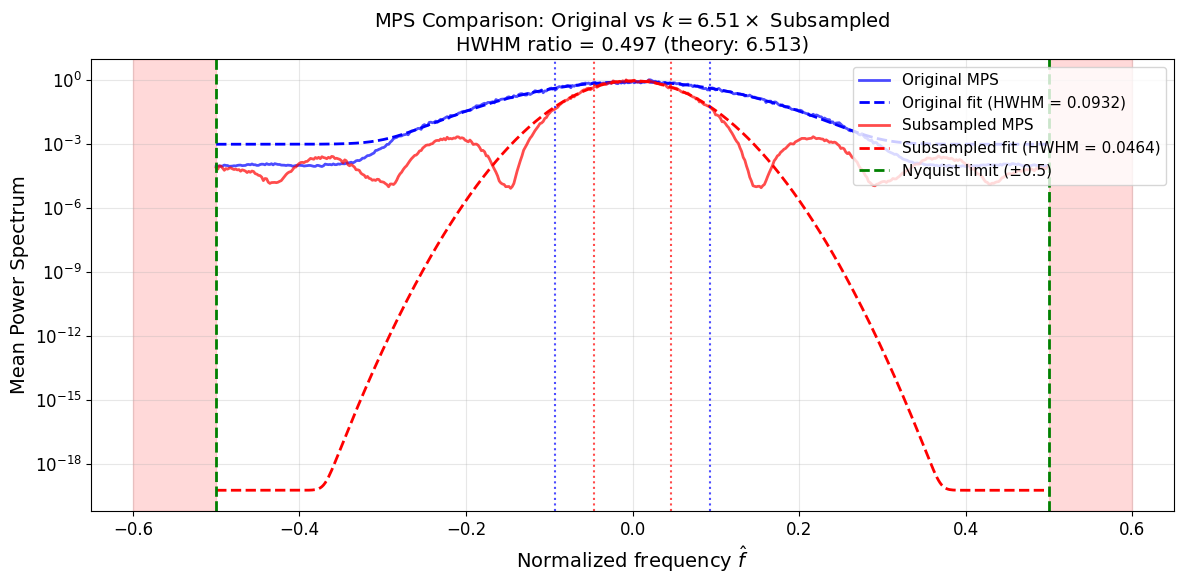

In [106]:
# Final comparison plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot MPS data
ax.semilogy(freq_orig, mps_orig, 'b-', linewidth=2, alpha=0.7, label='Original MPS')
ax.semilogy(fit_orig_val.freq_axis, fit_orig_val.fit_curve, 'b--', linewidth=2,
            label=f'Original fit (HWHM = {fit_orig_val.hwhm:.4f})')

ax.semilogy(freq_sub, mps_sub, 'r-', linewidth=2, alpha=0.7, label='Subsampled MPS')
ax.semilogy(fit_sub_val.freq_axis, fit_sub_val.fit_curve, 'r--', linewidth=2,
            label=f'Subsampled fit (HWHM = {fit_sub_val.hwhm:.4f})')

# Reference lines
ax.axvline(0.5, color='green', linestyle='--', linewidth=2, label='Nyquist limit (±0.5)')
ax.axvline(-0.5, color='green', linestyle='--', linewidth=2)

# HWHM markers
ax.axvline(fit_orig_val.hwhm, color='blue', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(-fit_orig_val.hwhm, color='blue', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(fit_sub_val.hwhm, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(-fit_sub_val.hwhm, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Shade aliasing region
ax.axvspan(-0.6, -0.5, alpha=0.15, color='red')
ax.axvspan(0.5, 0.6, alpha=0.15, color='red')

ax.set_xlabel(r'Normalized frequency $\hat{f}$', fontsize=14)
ax.set_ylabel('Mean Power Spectrum', fontsize=14)
ax.set_title(f'MPS Comparison: Original vs $k={k_use:.2f}\\times$ Subsampled\n'
             f'HWHM ratio = {ratio_actual:.3f} (theory: {k_use:.3f})', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_xlim([-0.65, 0.65])

plt.tight_layout()
plt.show()

---
# Summary: Key Equations
---

## Gaussian Relationships

| Quantity | Formula |
|----------|--------|
| Gaussian | $g(x) = A\exp(-x^2/(2\sigma^2))$ |
| HWHM from σ | $\text{HWHM} = \sigma\sqrt{2\ln 2} \approx 1.1774\sigma$ |
| σ from HWHM | $\sigma = \text{HWHM}/\sqrt{2\ln 2} \approx 0.8493 \cdot \text{HWHM}$ |
| FWHM | $\text{FWHM} = 2 \cdot \text{HWHM} = 2\sigma\sqrt{2\ln 2}$ |

## Sampling Theory

| Quantity | Formula |
|----------|--------|
| Nyquist frequency | $f_N = f_s/2$ |
| Normalized frequency | $\hat{f} = f/f_s \in [-0.5, 0.5]$ |
| Proper sampling | $\widehat{\text{HWHM}} < 0.5$ |
| Undersampling | $\widehat{\text{HWHM}} > 0.5$ |

## Subsampling

| Quantity | Formula |
|----------|--------|
| HWHM after subsampling | $\widehat{\text{HWHM}}_k = k \cdot \widehat{\text{HWHM}}_0$ |
| Critical factor | $k_{\text{crit}} = 0.5 / \widehat{\text{HWHM}}_0$ |
| Required factor for target | $k = \widehat{\text{HWHM}}_{\text{target}} / \widehat{\text{HWHM}}_0$ |